In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [22]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [19]:
import os
import json
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import pandas as pd

In [20]:
base_drive = "/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN"

dossiers_modeles = [
    "resultats_25_enrichi_quaero_fusioné",
    "resultats_50_enrichi_quaero_fusioné",
    "resultats_75_enrichi_quaero_fusioné",
    "resultats_complet_enrichi_quaero_fusioné",
    "resultats_REF_enrichi_quaero_fusioné",
    "resultats_Tesseract_enrichi_quaero_fusioné",
    "resultats_Kraken_enrichi_quaero_fusioné",
]
versions_OCR = ["REF", "TESSERACT", "KRAKEN"]

In [15]:
nom_dossier_model = "Modele_enrichi_quaero_fusioné"
sortie_dir = os.path.join(base_drive, "barplot_partition_entrainement", nom_dossier_model)
os.makedirs(sortie_dir, exist_ok=True)

In [7]:
couleurs_labels = {
    "PER": "#1f77b4",     # bleu
    "LOC": "#2ca02c",     # vert
    "ORG": "#ff7f0e",     # orange
    "MISC": "#9467bd",    # violet
    "DATE": "lightgrey"   # gris clair
}

In [8]:
def normaliser_label(label):
    if label.startswith("LOC"):
        return "LOC"
    return label

def compter_labels(json_path):
    cpt = Counter()
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)
            entities = data.values() if isinstance(data, dict) else data
            for ent in entities:
                labels = ent.get("label", "")
                if isinstance(labels, list):
                    for l in labels:
                        cpt[normaliser_label(l)] += 1
                elif isinstance(labels, str):
                    for l in labels.split(","):
                        cpt[normaliser_label(l.strip())] += 1
    except Exception as e:
        print(f"Erreur avec {json_path} : {e}")
    return cpt

<ipython-input-24-eb6f9494bf68>:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(index=modeles, columns=labels_possibles).fillna(0)


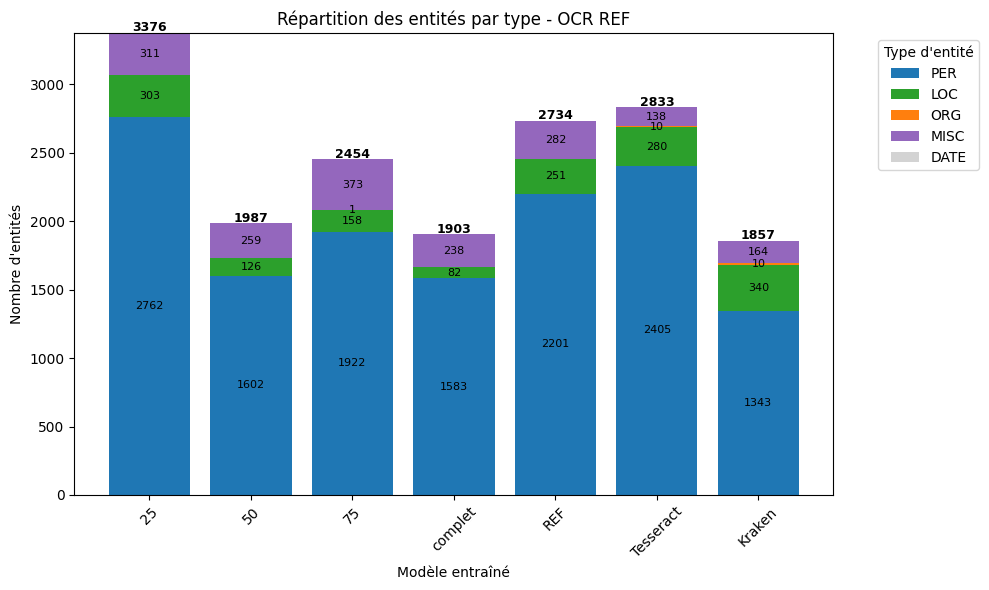

<ipython-input-24-eb6f9494bf68>:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(index=modeles, columns=labels_possibles).fillna(0)


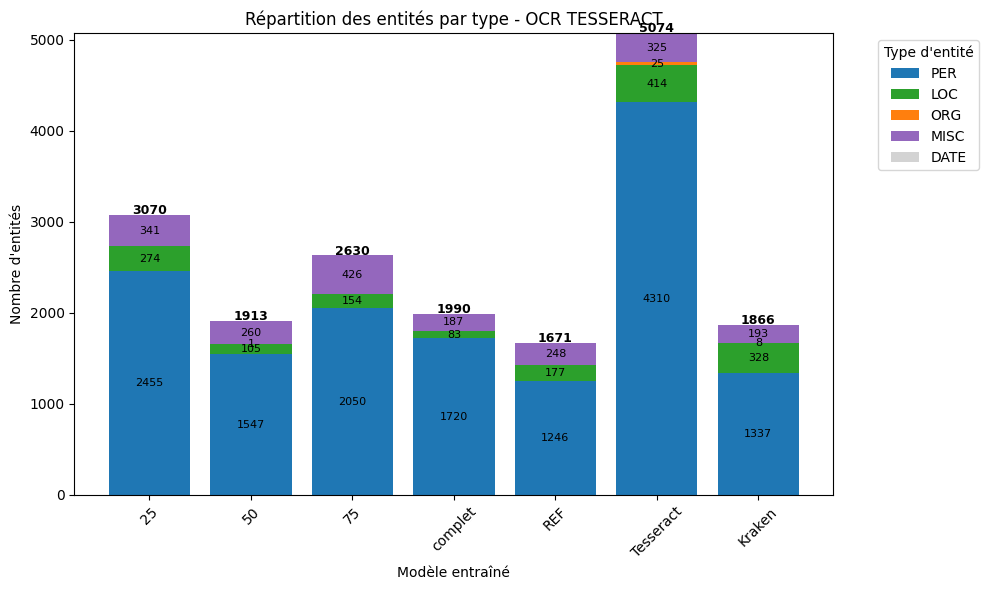

<ipython-input-24-eb6f9494bf68>:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(index=modeles, columns=labels_possibles).fillna(0)


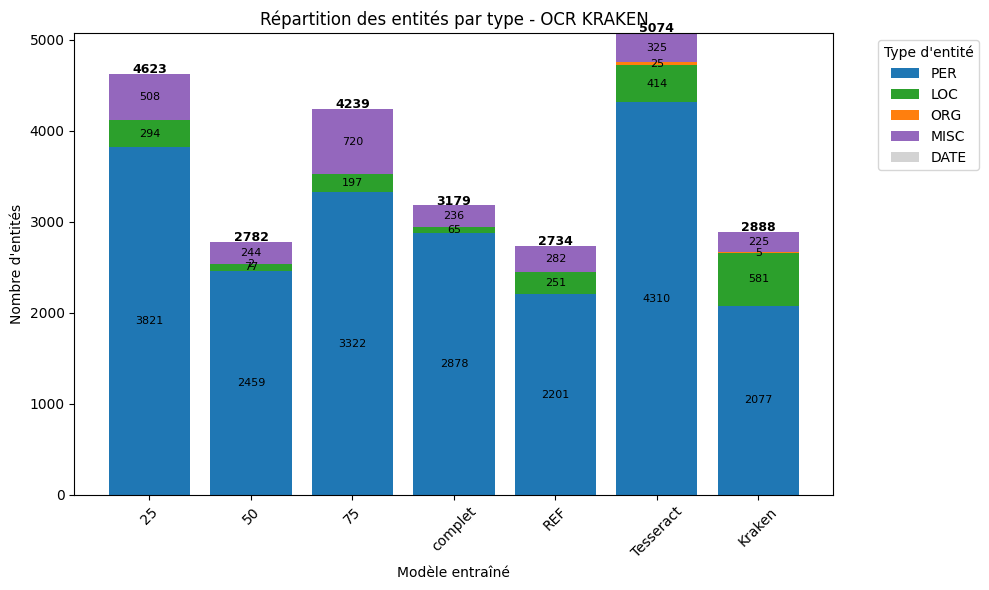

In [24]:
donnees = {ocr: defaultdict(Counter) for ocr in versions_OCR}

# Remplir les données
for dossier in dossiers_modeles:
    nom_modele = dossier.replace("resultats_", "").replace("_enrichi_quaero_fusioné", "")
    for ocr in versions_OCR:
        for fichier in os.listdir(os.path.join(base_drive, dossier)):
            if ocr in fichier.upper():
                chemin_fichier = os.path.join(base_drive, dossier, fichier)
                compte = compter_labels(chemin_fichier)
                donnees[ocr][nom_modele] = compte

# Création des barplots empilés
for ocr in versions_OCR:
    data_plot = donnees[ocr]
    modeles = list(data_plot.keys())
    labels_possibles = list(couleurs_labels.keys())

    df = pd.DataFrame(index=modeles, columns=labels_possibles).fillna(0)
    for modele, compte in data_plot.items():
        for label in labels_possibles:
            df.loc[modele, label] = compte.get(label, 0)

    fig, ax = plt.subplots(figsize=(10, 6))
    bas = [0] * len(df)
    for label in labels_possibles:
        ax.bar(df.index, df[label], bottom=bas, label=label, color=couleurs_labels[label])
        for i, val in enumerate(df[label]):
            if val > 0:
                ax.text(i, bas[i] + val / 2, int(val), ha='center', va='center', fontsize=8)
        bas = [i + j for i, j in zip(bas, df[label])]

    for i, modele in enumerate(df.index):
        total = df.loc[modele].sum()
        ax.text(i, total + 10, str(int(total)), ha='center', fontsize=9, weight='bold')

    ax.set_title(f"Répartition des entités par type - OCR {ocr}")
    ax.set_ylabel("Nombre d'entités")
    ax.set_xlabel("Modèle entraîné")
    ax.legend(title="Type d'entité", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(sortie_dir, f"barplot_REN_par_label_{ocr}.png"), dpi=300)
    plt.show()